# Ch 13 Processing Sequences w/ RNNs and CNNs

RNNs - Recurrent Neural Nets

Good for future prediction of time series - or any sequences, like sentences, documents, audio

In [2]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('CUDA version:', torch.version.cuda)
    print('Device count:', torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f'  cuda:{i} — {props.name} | {props.total_memory / 1e9:.1f} GB VRAM')
print('CPU device: cpu')

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
Device count: 2
  cuda:0 — NVIDIA GeForce RTX 3090 | 25.3 GB VRAM
  cuda:1 — NVIDIA GeForce RTX 5070 | 12.3 GB VRAM
CPU device: cpu


## Recurrent Neurons and Layers

We have only been doing forward neural nets, but we can also add connections going backward

Simplest example: a neuron that receives two inputs: one normal input $x_1$ and its last output $\hat y_0$

This is easily turned into a layer, now the layer gets the input vector and the last output vector.

You also need two sets of weights, one for inputs and one for the last time step's outputs. Notation: $w_x$ and $w_{\hat y}$ The whole layer is represented with W matrix

Recurrent Layer Output:
$$ \hat y_t = \phi (W_x^Tx_t+W_{\hat y}^T\hat y_{t-1}+b) $$

Outputs for a layer for all instances in a mini batch:
$$ \hat Y_t  = \phi (X_tW_x +\hat Y_{t-1} W_{\hat y}+b)$$

- Yhat_t is an n_instances_in_batch x n_neurons matrix containing the layer output at time t.
- X_t is an n_instances_in_batch x n_input_features matrix
- W_x is an n_input_features x n_neurons matrix
- W_yhat is an n_neurons x n_neurons matrix (weights for outputs of previous time step)
- b is the bias term

This makes Y_hat at time t a function of every single input prior to it

### Memory Cells

Any part of a neural net that preserves some state across time steps is called a memory cell. Recurrent neurons are memory cells, but they have a hard time with memory longer than like 10 steps.

A cells state at time step t is notated at h_(t) (h for hidden). It is some function of the current inputs and the last state: $h_t = f(x_t, h_{t-1})$


### Input and Output Sequences

An RNN can take a sequence of inputs and can produce a sequence of outputs. Or you could ignore the sequence and just take the last output if you care about one vector. Or you could look for a single value, like a sentiment score after a sequence of review text. This is equence to sequence, sequence to vector, sequence to value

There's also input to sequence, just feed the same input vector in over and over. This can be useful for image captioning.

Bottom left to top right: sequence-sequence, sequence-vector, vector-sequence, and encoder-decoder
![image.png](attachment:image.png)

An encoder-decoder is a sequence-to-vector network followed by a vector-to-sequence network (the encoder and the decoder). One use of this is translation: give a sentence in english, the network converts this to a vector of values, then takes those values and outputs a sequence in mandarin.

## Training RNNs

To train an RNN, you have to "unroll" it thru time and then use regular backprop. This is called backpropagation thru time.

Normal forward pass -> decide which outputs are used for the Yhat -> calculate loss with Y vs Yhat

Each weight and bias gradient gets updated multiple times before gradient descent (ie first by Yhat2, then Yhat3, and so on)

## Forecasting a Time Series

Using CTA data for forecasting n passengers on bus and rail tomorrow:

In [3]:
import pandas as pd
df = pd.read_csv("/home/will/Desktop/ML_notes/MLNotes/datasets/CTA_Data.csv", parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)
df = df.drop_duplicates()
df["bus"] = df["bus"].apply(lambda x: x.replace(",", ""))
df["rail"] = df["rail"].apply(lambda x: x.replace(",", ""))
df["bus"] = pd.to_numeric(df["bus"], errors="coerce")
df["rail"] = pd.to_numeric(df["rail"], errors="coerce")

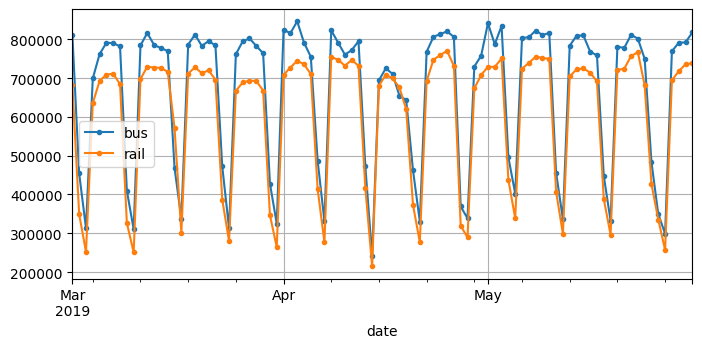

In [4]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

Naive forecasting: use last weeks values to get this weeks. Works pretty well here, you can use differencing and find that the MAPE (mean average % error) is ~9% for both


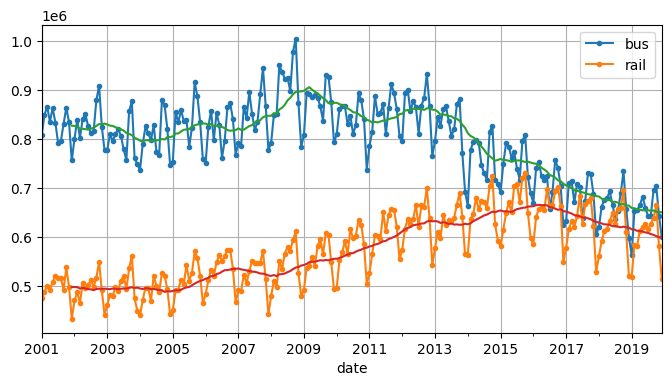

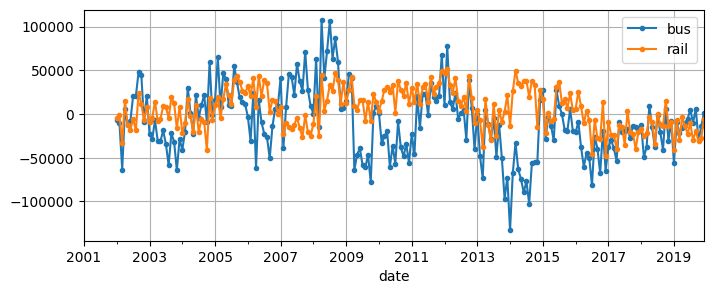

In [5]:
# checking for yrly seasonality

period = slice("2001", "2019")
df_monthly = df.select_dtypes(include="number").resample("ME").mean()
rolling_avg_12mo = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_avg_12mo.plot(ax=ax, grid=True, legend=False)
plt.show()

df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(8, 3))
plt.show()

In [6]:
from statsmodels.tsa.arima.model import ARIMA

origin, today = "2019-01-01", "2019-05-31"
rail_series = df.loc[origin:today]["rail"].asfreq("D")
model = ARIMA(rail_series, order=(1,0,0), seasonal_order=(0,1,1,7))
model = model.fit()
model.forecast() - df.loc["2019-06-01"]["rail"]
# df.loc["2019-06-01"]["rail"]
# off by almost 49k, 13%

2019-06-01    48714.626421
Freq: D, dtype: float64

In [7]:
# Testing ARIMA
origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")
y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today],  # train on data up to "today"
                  order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, 7))
    model = model.fit()  # note that we retrain the model every day!
    y_pred = model.forecast().iloc[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean()
mae
# This does better than naive forecasting by a large margin

np.float64(32040.720094289627)

### Preparing Data for ML Models

Two methods: naive and SARIMA.

In [8]:
# Geron's custom dataset to get time series data
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end]
        target = self.series[end]
        return window, target

In [9]:
# testing w/ 0,1,2,3,4,5
xt = torch.tensor([[0], [1], [2], [3], [4], [5]])
dataset = TimeSeriesDataset(xt, window_length=3)
for window, target in dataset:
  print(window, target)

tensor([[0],
        [1],
        [2]]) tensor([3])
tensor([[1],
        [2],
        [3]]) tensor([4])
tensor([[2],
        [3],
        [4]]) tensor([5])


In [10]:
from torch.utils.data import DataLoader
rail_train = torch.FloatTensor(df[["rail"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail"]]["2019-01":"2019-05"].values / 1e6)
rail_test = torch.FloatTensor(df[["rail"]]["2019-06":].values / 1e6)

window_length = 56 #8weeks
train_set = TimeSeriesDataset(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = TimeSeriesDataset(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32)
test_set = TimeSeriesDataset(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=32)

### Linear Model Forecasting

In [11]:
import torch.nn as nn
# !pip install torchmetrics
import torchmetrics
device = "cuda"
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(window_length,1)
).to(device) # Changed: explicitly move model to 'device'

loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=.003, momentum=.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

In [12]:
def train(model, data_loader, loss_fn, optimizer, metric, epochs):
    model.train()
    metrics = []
    for epoch in range(epochs):
      epoch_metrics = []
      for X_train, y_train in data_loader:
        X_train = X_train.to(device)
        y_train = y_train.to(device)
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_metrics.append(metric(y_pred, y_train).item())
      metrics.append(sum(epoch_metrics)/len(epoch_metrics))
    return metrics

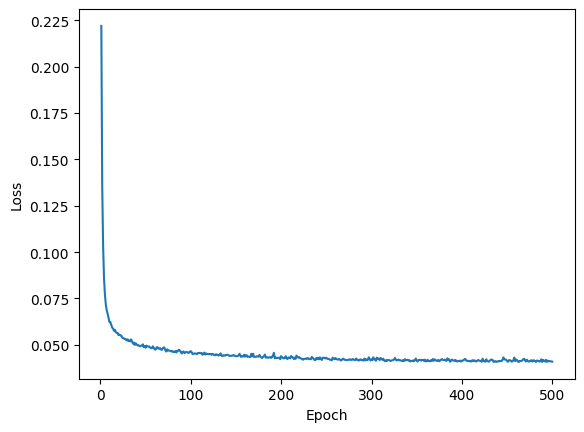

In [13]:
import numpy as np
losses = train(model, train_loader, loss_fn, optimizer, metric, 500)
plt.plot(np.arange(1,len(losses)+1), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [14]:
def validate(model, data_loader, loss_fn, metric):
    model.eval()
    validation_losses = []
    validation_metrics = []
    with torch.no_grad():
        for X_val, y_val in data_loader:
            X_val = X_val.to(device)
            y_val = y_val.to(device)
            y_pred = model(X_val)
            loss = loss_fn(y_pred, y_val)
            validation_losses.append(loss.item())
            validation_metrics.append(metric(y_pred, y_val).item())
    return sum(validation_losses) / len(validation_losses), sum(validation_metrics) / len(validation_metrics)

In [15]:
val_loss, val_metric = validate(model, valid_loader, loss_fn, metric)
print(f"Validation Metric (MAE): {val_metric*1e6:.4f}")

Validation Metric (MAE): 38290.7509


### Forecasting with an RNN

In [16]:
class SimpleRNNModel(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    # hidden size is number of recurrent neurons
    # only predicting 1 val, which is output size
    super().__init__()
    self.hidden_size = hidden_size
    self.memory_cell = nn.Sequential(
        nn.Linear(input_size + hidden_size, hidden_size),
        nn.Tanh() #tends to be more stable
    )
    self.output = nn.Linear(hidden_size, output_size)

  def forward(self, X):
    # these are from the dataloader
    batch_size, window_length, dimensionality = X.shape
    Xt_first = X.transpose(0,1)
    # hidden state is initialized to zeroes
    H = torch.zeros(batch_size, self.hidden_size, device=X.device)
    for X_t in Xt_first:
      XH = torch.cat((X_t, H), dim=1)
      H = self.memory_cell(XH)
    # then for each time step we give the current inputs
    # and the hidden state to the memory cell
    # the memory cell gives us the new hidden state
    return self.output(H)

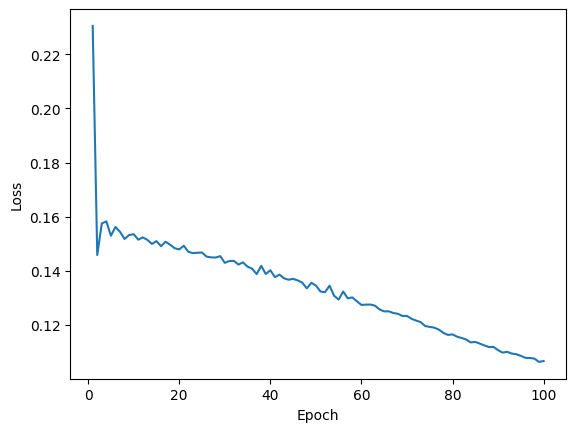

In [17]:
device = "cuda:1"
univariate_model = SimpleRNNModel(input_size=1, hidden_size=32, output_size=1)
univariate_model = univariate_model.to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(univariate_model.parameters(), lr=.003, momentum=.9) # Fixed: changed 'model.parameters()' to 'univariate_model.parameters()'
metric = torchmetrics.MeanAbsoluteError().to(device)
losses = train(univariate_model, train_loader, loss_fn, optimizer, metric, 100)
plt.plot(np.arange(1,len(losses)+1), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()
# 200 epochs got down to 62000 MAE but the loss curve suggested
# we could keep going

In [18]:
val_loss, val_metric = validate(univariate_model, valid_loader, loss_fn, metric)
print(f"Validation Metric (MAE): {val_metric*1e6:.4f}")

Validation Metric (MAE): 108835.0117


You can build a similar version of this with PyTorch's nn.RNN module, which is way more optimized, but functionally the same, as the one above


### Forecasting with a Deep RNN

In PyTorch, you can add multiple layers to your RNN by setting num_layers hyperparam of nn.RNN

Beats out the single layer model by a small margin.

In [19]:
input_size = 1
hidden_size = 32
nn.RNN(input_size, hidden_size, num_layers=3, batch_first=True)

RNN(1, 32, num_layers=3, batch_first=True)

### Forecasting Multivariate Time Series

RNNs can easily be changed to do multivariate time series

In [20]:
multivar_data = df[["rail", "bus"]] / 1e6
multivar_data["next_day_type"] = df["day_type"].shift(-1)
multivar_data = pd.get_dummies(multivar_data, dtype=float)

mulvar_train = torch.FloatTensor(multivar_data["2016-01":"2018-12"].values / 1e6)
mulvar_valid = torch.FloatTensor(multivar_data["2019-01":"2019-05"].values / 1e6)
mulvar_test = torch.FloatTensor(multivar_data["2019-06":].values / 1e6)

class MulvarTimeSeriesDataset(TimeSeriesDataset):
  def __getitem__(self, idx):
    window, target = super().__getitem__(idx)
    return window, target[:1] #only want to predict rail for now

In [21]:
mulvar_train_set = MulvarTimeSeriesDataset(mulvar_train, window_length)
mv_train_loader = DataLoader(mulvar_train_set, batch_size=32, shuffle=True)

mulvar_valid_set = MulvarTimeSeriesDataset(mulvar_valid, window_length)
mv_mulvar_valid_set_loader = DataLoader(mulvar_valid_set, batch_size=32)

mulvar_test_set = MulvarTimeSeriesDataset(mulvar_test, window_length)
mv_test_loader = DataLoader(mulvar_test_set, batch_size=32)


In [22]:
# You give it 5 inputs instead of 1
mv_model = SimpleRNNModel(input_size=5, hidden_size=32, output_size=1)
mv_model = mv_model.to(device)
# This model massively improves MAE
# To add bus predictions, just change
  # return window, target[:2]
  # and output_size = 2

# Usually predicting a related value can help a model's performance,
# But in this case it degrades when you predict 2 values

### Forecasting Several Time Steps Ahead

You could just keep feeding outputs back into model as inputs:

In [23]:
n_steps = 14
univariate_model.eval()
with torch.no_grad():
    X = rail_valid[:window_length].unsqueeze(dim=0).to(device) #unsqueeze to add batch dimension
    for step_ahead in range(n_steps):
        y_pred_one = univariate_model(X)
        X = torch.cat([X, y_pred_one.unsqueeze(dim=0)], dim=1)

    Y_pred = X[0, -n_steps:, 0]

Or you could predict the next 14 values in one shot:

In [24]:
class ForecastAhead(TimeSeriesDataset):
    def __len__(self):
        return len(self.series) - self.window_length - 14 + 1
    
    def __getitem__(self, idx):
        end = idx + self.window_length
        window = self.series[idx : end]
        target = self.series[end : end + 14, 0] # 0 corresponds to rail column
        return window, target

In [ ]:
ahead_train = ForecastAhead(mulvar_train, window_length)
ahead_train_loader = DataLoader(ahead_train, batch_size=32, shuffle=True)
ahead_model = SimpleRNNModel(input_size=5, hidden_size=32, output_size=14)
# also make validation sets
ahead_model = ahead_model.to(device)
# and eval with torch.no_grad() 

### Forecasting Using Sequence-to Sequence Models

Model now takes in inputs, and the target is a same sized sequence but each step is a vector of the next 14 preds

For a sequence to vector model: 
- Input:  [t₁, t₂, t₃, ..., t_W]
- Target:                         [t_{W+1}, ..., t_{W+14}]

For seq-seq:
- Input:   [t₁,  t₂,  t₃,  ...,  t_W]
- Targets: [t₂…t₁₅, t₃…t₁₆, t₄…t₁₇, ..., t_{W+1}…t_{W+14}]

The biggest advantage is: now you have gradients for each time step

In [ ]:
class Seq2SeqDataset(ForecastAhead):
    def __getitem__(self, idx):
        end = idx + self.window_length  
        window = self.series[idx : end]
        target_period = self.series[idx + 1 : end + 14, 0]
        target = target_period.unfold(dimension=0, size=14, step=1)
        return window, target

In [33]:
# an example of what unfold is doing here
torch.tensor([0, 1, 2, 3, 4, 5]).unfold(dimension=0, size=4, step=1)

tensor([[0, 1, 2, 3],
        [1, 2, 3, 4],
        [2, 3, 4, 5]])

In [ ]:
# the actual model is only a little different

class Seq2SeqModel(SimpleRNNModel):
    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs)

The self.output layer is now applied to every time step now

- so far only have applied nn.Linear on 2d inputs, but now outputs is 3D [batch size, window length, hidden size]
- this works because nn.Linear will just apply itself to each step automatically

nn.Linear relies on torch.matmul(), which can do things like multiply matrices with shape [2,3,5,7] by [2,3,7,11]
- Think of these as both 2x3 grids of matrices
- The final result is a 2x3 grid of 5x11 matrices (5x7 by 7x11)

Broadcasting also works
- [10, 56, 32] can be multiplied by [32, 14], and the result is a [10, 56, 14]
- You are just doing 10 56x32 by 32x14 mults


This gives us a good test MAE performance for the 14 day sequence, but RNNs struggle with longer sequences

## Handling Long Sequences

Unrolled RNNs make a very deep network, which leads to gradient issues, or forgetting the first inputs in a long sequence

### Fighting Unstable Gradients
- You can use some of the deep NN tricks here: good initialization, faster optimizers, dropout
- Nonsaturating Activation Functions (ReLU): Doesnt help at all
    - Ex: Gradients change weights so that first step increase output values by 1%
    - But since this is a sequence, now all future steps have increased output by 1%
- You can use a lower LR, or a saturating activation function like tanh
- Gradients may explode and you need gradient clipping
- Batch norm also not as helpful: cant use it between time steps, only btwn recurrent layers
    - Why? Theres some research, applying BN to inputs kinda helped, hidden state didnt
- Layer norm tends to work a little better than BN, apply it before activation function
    - unfortunately you have to build it yourself:

In [35]:
# # inside the RNN memory cell
# self.memory_cell = nn.Sequential(
#     nn.Linear(input_size + hidden_size, hidden_size),
#     nn.LayerNorm(hidden_size).
#     nn.Tanh()
# )

Note: LN doesn't always help, but it can help in GATED RNNs like LSTM and GRU

- Also works better on stationary time series

### The Short Term Memory Problem

Since RNNs gradually lose info on the early inputs, it can help to have some way to store long term memory

#### LSTM Cells

nn.LSTM is a drop-in replacement for nn.RNN

Two state vectors: $h_{(t)}$ and $c_{(t)}$

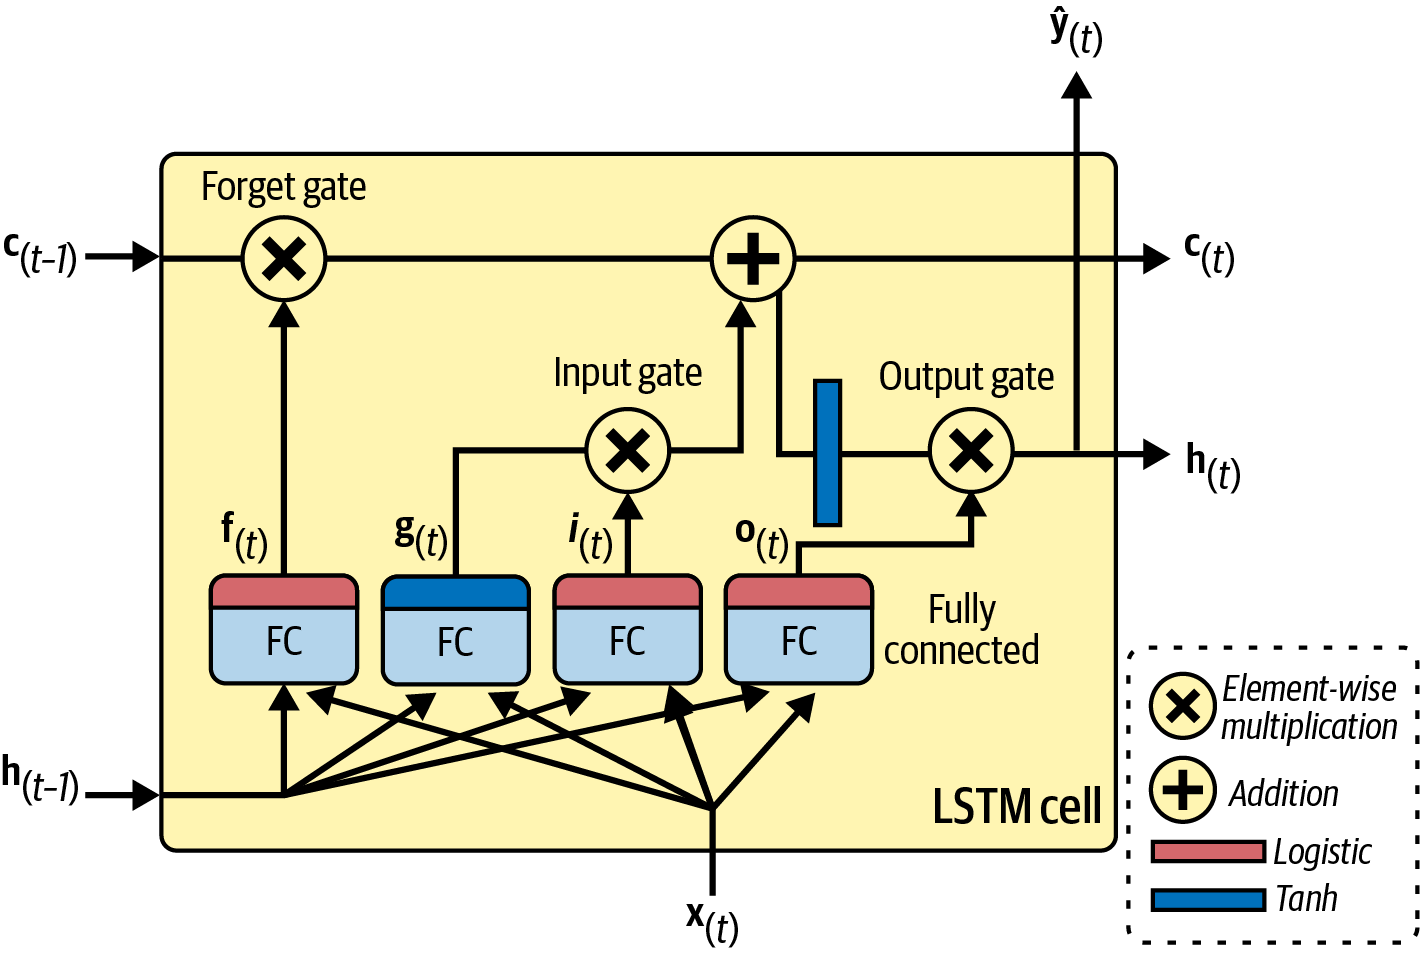

Where c is the long term state and h is the hidden state. The idea is that the network can now: Learn what to keep in long term, what to throw away, and what to read from c

As the last long-term memory goes from left to right, it: Forgets some memories, adds some new memories that went through an input gate, and then its done!

Also, after the addition, c is copied and passed through tanh function, and this result is filtered by the output gate, produces the hidden state (and output) h

How are memories made? x_t and h_t-1 are fed into four fully connected layers:
- Main layer is g_(t), it combines x and h, and in a simple RNN the only layer is g. The most important parts of g are kept in c
- Other 3 layers are gate controllers, and they all use the logistic function and element wise multiplication. This means they have 0-1 values, where 0's close the gate
    - f - forget gate, controls which long term memory should be erased
    - i - input gate, controls which parts of g should be a part of long term memory
    - o - controls which parts of c should be used to create h (and y)

Basically: The LSTM learns to recognize important parts of the input (i), keep it in memory, get rid of memory when it isnt needed anymore (f), and is fully differentiable.

LSTM Equations:

$ i_{(t)} = \sigma (W_{xi}^T x_{(t)} + W_{hi}^T h_{(t-1)} + b_i) $

$ f_{(t)} = \sigma (W_{xf}^T x_{(t)} + W_{hf}^T h_{(t-1)} + b_f) $

$ o_{(t)} = \sigma (W_{xo}^T x_{(t)} + W_{ho}^T h_{(t-1)} + b_o) $

$ g_{(t)} = tanh (W_{xg}^T x_{(t)} + W_{hg}^T h_{(t-1)} + b_g) $

$ c_{(t)} = f_{(t)} \odot c_{(t-1)} + i_{(t)} \odot g_{(t)} $

$ y_{(t)} = h_{(t)} = o_{(t)} \odot tanh(c_{(t)}) $

- Note if the hidden state is modified anyway before output, y_t does not equal h_t

An implementation of LSTMs without nn.LSTM (if you want to add dropout, or layer norm)

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.LSTMCell(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)
    
    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        Xt_first = X.transpose(0,1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        C = torch.zeros(batch_size, self.hidden_size, device=X.device) # cell state
        for X_t in Xt_first:
            H, C = self.memory_cell(X_t, (H, C))
        return self.output(H)

Very similar to the RNN, but now you have two hidden states

#### GRU cells

Gated Recurrent Unit - a popular LSTM variant

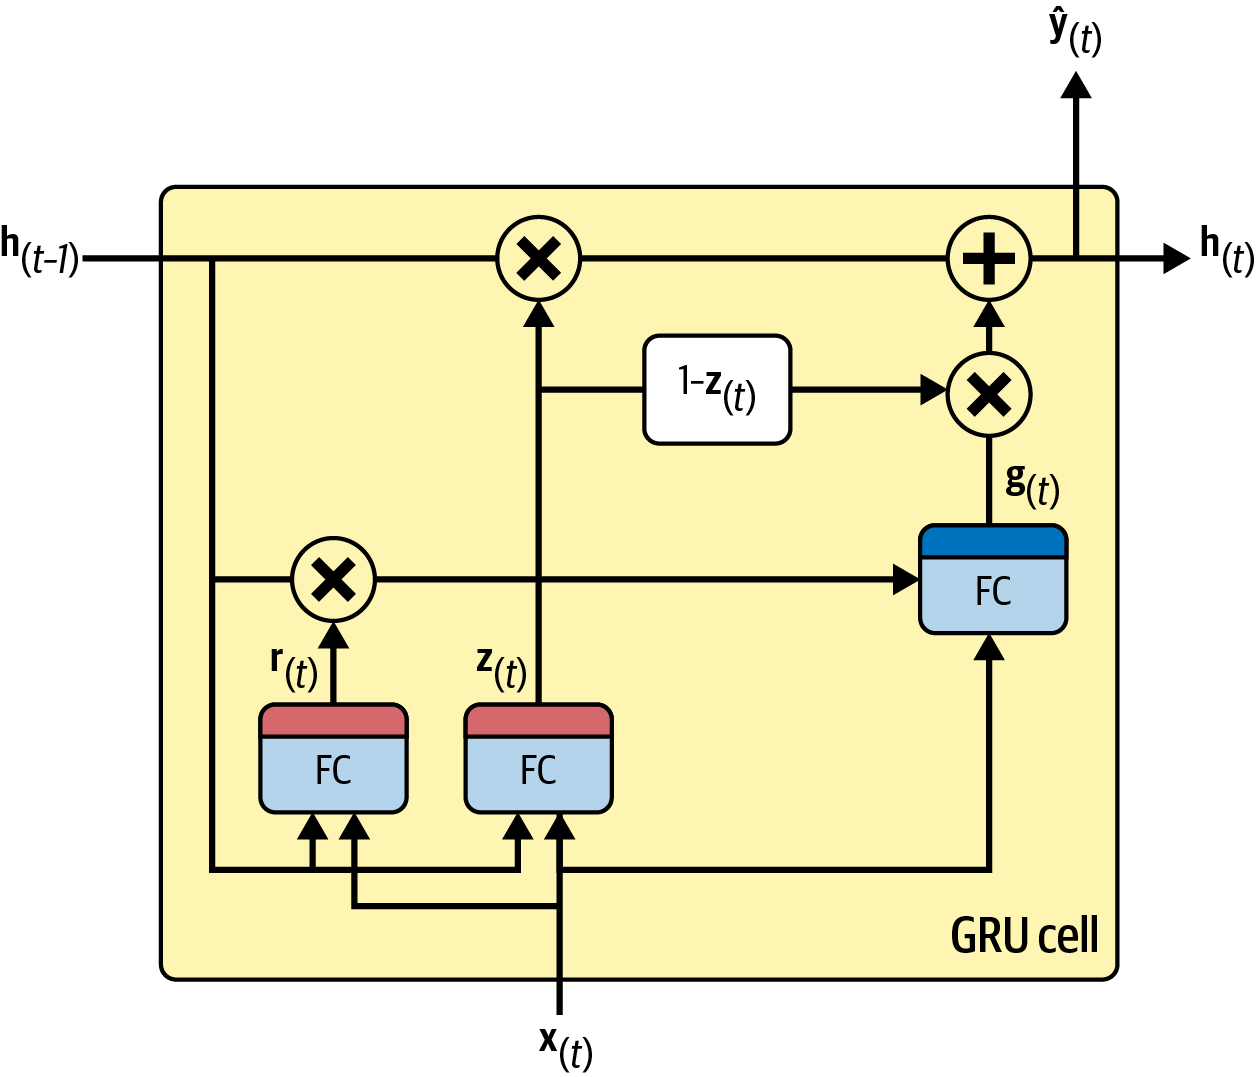

It simplifies the LSTM by:
- combining h and c into one vector
- one gate controller z controls the forget and input gate, where forget = 1 - input
- no output gate, full state vector is the output
    - but a new gate controller r that controls which part of last state is shown to main layer g


$z_{(t)} = \sigma(W_{xz}^T x_{(t)} + W_{hz}^T h_{(t-1)} + b_z)$

$r_{(t)} = \sigma(W_{xr}^T x_{(t)} + W_{hr}^T h_{(t-1)} + b_r)$

$g_{(t)} = \tanh(W_{xg}^T x_{(t)} + W_{hg}^T (r_{(t)} \odot h_{(t-1)}) + b_g)$

$h_{(t)} = (1 - z_{(t)}) \odot h_{(t-1)} + z_{(t)} \odot g_{(t)}$

The underlying idea is that whatever you want to forget is probably related to whatever new info you have

However, these models also have a hard time learning patterns of >100 steps

#### 1D Conv for Sequence Processing

1d convs work like 2d convs: slide feature maps across the 1d sequence input.
- Each kernel learns to detect a very short sequential pattern
- Use 10 kernels: layer output is 10 1D sequences

Keep in mind nn.Conv1d expects [batch size, input features, sequence length]. so youll have to swap the last two dimensions of the inputs/outputs

Example: 1d conv, followed by GRU, followed by linear output
- This takes in a batch of sequences, conv downsamples by a factor of 2 (w/ stride 2)

In [ ]:
class DownsamplingModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.conv = nn.Conv1d(input_size, hidden_size, kernel_size=4, stride=2)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        Z = X.permute(0, 2, 1)  # treat time as a spatial dimension
        Z = self.conv(Z)
        Z = Z.permute(0, 2, 1)  # swap back time & features dimensions
        Z = torch.relu(Z)
        Z, _states = self.gru(Z) #ignore hidden states
        return self.linear(Z)

torch.manual_seed(42)
dseq_model = DownsamplingModel(input_size=5, hidden_size=32, output_size=14)
dseq_model = dseq_model.to(device)

Shortening the time series with convolution helps the GRU layer detect longer patterns.

We MUST remove the first three time steps from the target since the kernel size is 4, so we need a new dataset:

In [ ]:
class DownsampledDataset(Seq2SeqDataset):
    def __getitem__(self, idx):
        window, target = super().__getitem__(idx)
        return window, target[3::2]  # crop the first 3 targets and downsample by taking every 2nd element

window_length = 112
dseq_train_set = DownsampledDataset(rail_train, window_length)
dseq_train_loader = DataLoader(dseq_train_set, batch_size=32, shuffle=True)

### WaveNet

Who needs recurrent layers when you can just keep stacking convolutional layers?

- Double the dilation rate of each sequential layer, so you get an architecture that looks like this: 

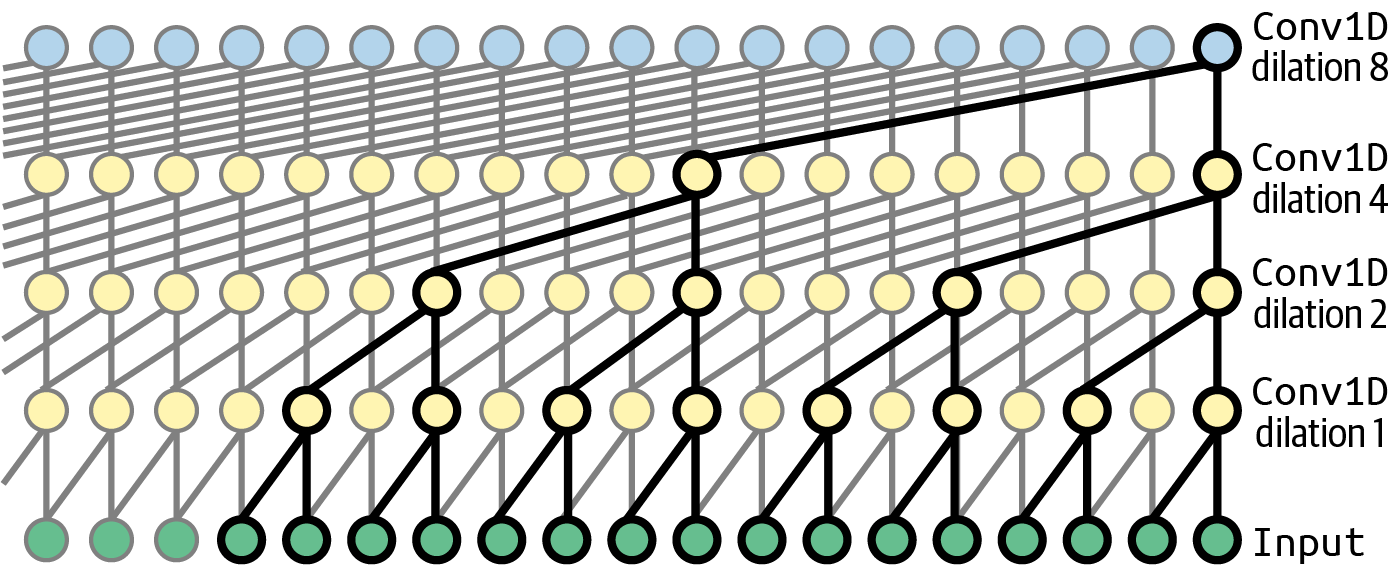

- Lower layers learn short patterns, higher ones learn long patterns

Make sure to pad the left side of the input with zeroes, number equal to the dilation rate, to keep the same sequence length

A custom WaveNet implementation, using a custom Conv1d that adds padding

In [ ]:
import torch.nn.functional as F

class CausalConv1d(nn.Conv1d):
    def forward(self, X):
        padding = (self.kernel_size[0] - 1) * self.dilation[0]
        X = F.pad(X, (padding, 0)) # the padding makes the model causal
        return super().forward(X)
    
class WavenetModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        layers = []
        for dilation in (1, 2, 4, 8) * 2: # makes 8 layers
            conv = CausalConv1d(input_size, hidden_size, kernel_size=2,
                                dilation=dilation)
            layers += [conv, nn.ReLU()]
            input_size = hidden_size
        self.convs = nn.Sequential(*layers)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        Z = X.permute(0, 2, 1)
        Z = self.convs(Z) # need to permute 
        Z = Z.permute(0, 2, 1)
        return self.output(Z)

torch.manual_seed(42)
wavenet_model = WavenetModel(input_size=5, hidden_size=32, output_size=14)
wavenet_model = wavenet_model.to(device)


Importantly, padding makes it so each output is the same length, so the targets dont have to be downsampled/cropped

WaveNet can be used to generate music, shown in the original paper

Exercises

Can you think of a few applications for a sequence-to-sequence RNN? What about a sequence-to-vector RNN, and a vector-to-sequence RNN?

    Sequence to sequence -> Basically any time series prediction. Weather, stocks, MTL, music gen
    Sequence to vector -> Classifying any sequence, like review sentiment
    Vector to sequence -> Image captioning, making a playlist based on current music taste

How many dimensions must the inputs of an RNN layer have? What does each dimension represent? What about its outputs?

    3 Dimensions: batch dimension, time (number of steps), inputs per step.
    Output depends on if its a sequence to sequence or sequence to vector, but is still 3D

How can you build a deep sequence-to-sequence RNN in PyTorch?

    Need a custom dataloader that returns sequences rather than vectors as targets, and then use an RNN, LSTM, or GRU module. If you want regularization, need to make a custom class with RNNCell or LSTMCell or GRUCell, and make the recurrent loop manually.

Suppose you have a daily univariate time series, and you want to forecast the next seven days using an RNN. Which architecture should you use?

    Sequence to vector, with a simple RNN, 7 neurons in the output layer. 

What are the main difficulties when training RNNs? How can you handle them?

    Forgetting input data with long sequences? Use LSTM or GRU.
    Gradient issues? Layer Norm, Better Initialization, Use Saturating Activation Functions, Dropout, Learning Rate changes

Why would you want to use 1D convolutional layers in an RNN?

    An RNN is sequential, meaning it needs the outputs of all previous time steps to find the output at time step t. However, a Conv1d layer doesn't need to be sequential, it has no memory.

Which neural network architecture could you use to classify videos?

    Possible answer: Sample frames at a certain interval (or use all the frames), run those frames through a CNN, feed CNN outputs as a time series to an RNN. Use cross entropy as the loss, softmax as the output for class probabilities at the end.

